# 05 - Validacion

**TP2 - Modulo 2 - Clasificacion `smoking`**

Evaluamos el modelo con los datos que apartamos en el notebook 04. Tambien ajustamos el threshold de decision porque el 0.5 por defecto no siempre da el mejor F1 cuando hay desbalance.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, ConfusionMatrixDisplay)

import utils
from utils import DATA_PROCESSED, MODELS, MODELS_XGB, IMGS

X_val = pd.read_csv(DATA_PROCESSED / 'X_val.csv')
y_val = pd.read_csv(DATA_PROCESSED / 'y_val.csv').iloc[:, 0]
print('val:', X_val.shape)

val: (10000, 32)


## Carga del modelo

In [2]:
modelo = joblib.load(MODELS_XGB / 'xgb_pipeline.joblib')

## Metricas con threshold 0.5

In [3]:
proba_val = modelo.predict_proba(X_val)[:, 1]
pred = (proba_val >= 0.5).astype(int)

tabla = pd.DataFrame([{
    'modelo': 'XGBoost',
    'f1_clase1': f1_score(y_val, pred, pos_label=1),
    'roc_auc': roc_auc_score(y_val, proba_val),
    'pr_auc': average_precision_score(y_val, proba_val),
}])
tabla

,modelo,f1_clase1,roc_auc,pr_auc
0,XGBoost,0.734834,0.874524,0.779472


## Busqueda del mejor threshold

Probamos todos los posibles thresholds usando la curva precision-recall y nos quedamos con el que maximiza el F1 de la clase 1.

In [4]:
prec, rec, thr = precision_recall_curve(y_val, proba_val)
f1s = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
best_idx = np.argmax(f1s[:-1])
best_thr = float(thr[best_idx])
print('Threshold optimo:', round(best_thr, 4))
print('F1 a 0.50       :', round(f1_score(y_val, (proba_val >= 0.5).astype(int), pos_label=1), 4))
print('F1 al optimo    :', round(f1_score(y_val, (proba_val >= best_thr).astype(int), pos_label=1), 4))

Threshold optimo: 0.4248
F1 a 0.50       : 0.7348
F1 al optimo    : 0.742


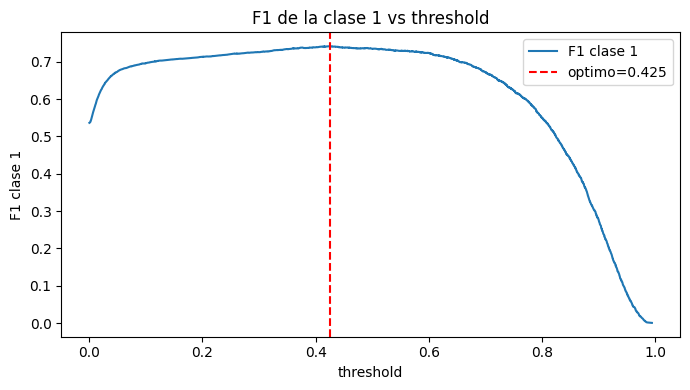

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thr, f1s[:-1], label='F1 clase 1')
ax.axvline(best_thr, color='red', ls='--', label=f'optimo={best_thr:.3f}')
ax.set_xlabel('threshold')
ax.set_ylabel('F1 clase 1')
ax.set_title('F1 de la clase 1 vs threshold')
ax.legend()
fig.tight_layout()
fig.savefig(IMGS / 'threshold_f1.png', dpi=120)
plt.show()

## Reporte y matriz de confusion con el threshold elegido

              precision    recall  f1-score   support

           0     0.9113    0.7155    0.8016      6334
           1     0.6415    0.8797    0.7420      3666

    accuracy                         0.7757     10000
   macro avg     0.7764    0.7976    0.7718     10000
weighted avg     0.8124    0.7757    0.7798     10000



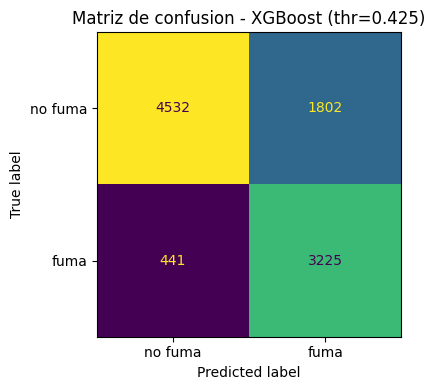

In [6]:
pred_final = (proba_val >= best_thr).astype(int)
print(classification_report(y_val, pred_final, digits=4))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_val, pred_final),
                       display_labels=['no fuma', 'fuma']).plot(ax=ax, colorbar=False)
ax.set_title(f'Matriz de confusion - XGBoost (thr={best_thr:.3f})')
fig.tight_layout()
fig.savefig(IMGS / 'confusion_matrix.png', dpi=120)
plt.show()

## Guardado

## Curvas ROC y Precision-Recall

Visualizamos la capacidad del modelo para distinguir las dos clases a distintos thresholds.

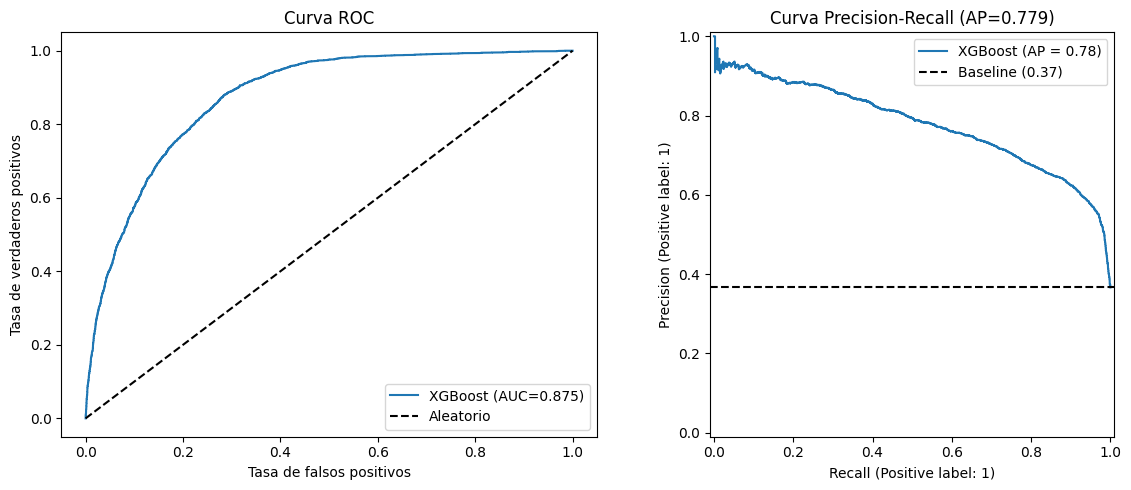

In [7]:
from sklearn.metrics import roc_curve, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_val, proba_val)
auc_roc = roc_auc_score(y_val, proba_val)
axes[0].plot(fpr, tpr, label=f'XGBoost (AUC={auc_roc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Aleatorio')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].set_title('Curva ROC')
axes[0].legend()

# Curva Precision-Recall
pr_auc = average_precision_score(y_val, proba_val)
PrecisionRecallDisplay.from_predictions(y_val, proba_val, name='XGBoost', ax=axes[1])
axes[1].axhline(y_val.mean(), color='k', linestyle='--', label=f'Baseline ({y_val.mean():.2f})')
axes[1].set_title(f'Curva Precision-Recall (AP={pr_auc:.3f})')
axes[1].legend()

fig.tight_layout()
fig.savefig(IMGS / 'curvas_roc_pr.png', dpi=120)
plt.show()

In [8]:
joblib.dump(modelo, MODELS / 'best_model.joblib')
with open(MODELS / 'decision_threshold.json', 'w') as f:
    json.dump({'modelo': 'XGBoost', 'threshold': best_thr}, f, indent=2)
print('Guardados best_model.joblib y decision_threshold.json')

Guardados best_model.joblib y decision_threshold.json


## Resumen

- F1 clase 1 con threshold 0.50: **0.7348**
- F1 clase 1 con threshold optimo (0.4248): **0.742**
- ROC-AUC: 0.875 | PR-AUC: 0.779
- Bajar el threshold a 0.4248 hace que el modelo sea mas agresivo detectando fumadores (mas recall), lo que mejora el F1.
- Limitacion: el threshold lo ajustamos sobre el mismo set de validacion, asi que el 0.742 es optimista en ese sentido.

## Feature importance

Miramos cuales variables usa mas el modelo. Usamos frecuencia de uso en splits porque es mas estable que el gain cuando hay variables muy dominantes.

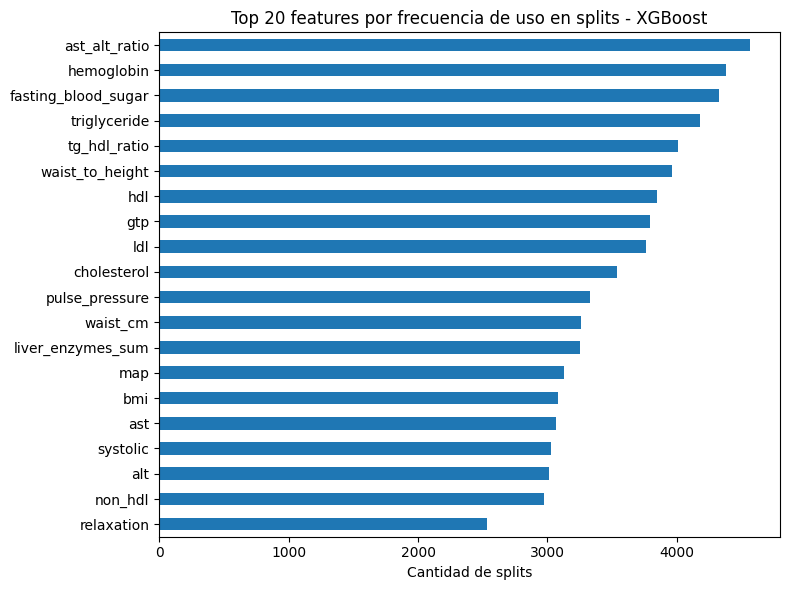

In [9]:
clf = modelo.named_steps['clf']
prep = modelo.named_steps['prep']

# Nombres de features tras el ColumnTransformer (numericas primero, luego one-hot).
num_names = prep.transformers_[0][2]
cat_names = list(prep.transformers_[1][1].named_steps['ohe'].get_feature_names_out(
    prep.transformers_[1][2]))
feature_names = num_names + cat_names

# weight: cantidad de veces que cada feature se usa en un split (mas estable que gain).
importance = pd.Series(
    clf.get_booster().get_score(importance_type='weight'),
    index=None
)
# get_score devuelve nombres internos (f0, f1...) si no se setearon; los reemplazamos.
clf.get_booster().feature_names = feature_names
importance = pd.Series(
    clf.get_booster().get_score(importance_type='weight')
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
importance.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 20 features por frecuencia de uso en splits - XGBoost')
ax.set_xlabel('Cantidad de splits')
fig.tight_layout()
fig.savefig(IMGS / 'feature_importance.png', dpi=120)
plt.show()